# Eigenfraud — Single-Image Inference

Runs `REAL.png` and `FAKE.png` through both the 1D and 2D checkpoints.
Shows the input images, their frequency representations, and the model predictions.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from src.transforms import to_grayscale_array, log_power_spectrum_2d, azimuthal_average_fast
from src.models import build_model

REPO_ROOT = os.path.abspath('..')
IMAGES = {
    'REAL.png': 'real',
    'FAKE.png': 'fake',
}
CHECKPOINTS = [
    os.path.join(REPO_ROOT, 'results', 'best_1d.pt'),
    os.path.join(REPO_ROOT, 'results', 'best_2d.pt'),
]
device = torch.device('cpu')
print('Setup complete.')

Setup complete.


## 1. Input Images

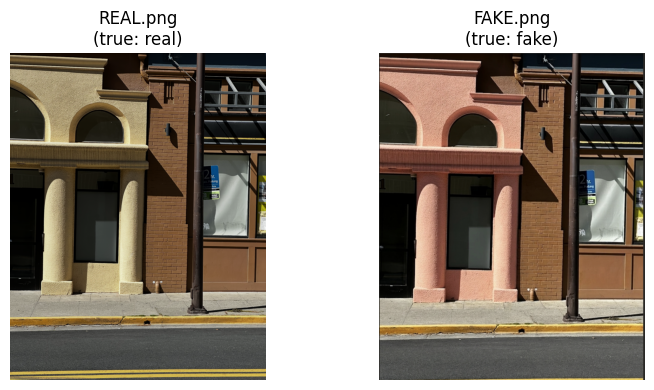

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (fname, true_label) in zip(axes, IMAGES.items()):
    img = Image.open(os.path.join(REPO_ROOT, fname))
    ax.imshow(img)
    ax.set_title(f'{fname}\n(true: {true_label})', fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Frequency Representations

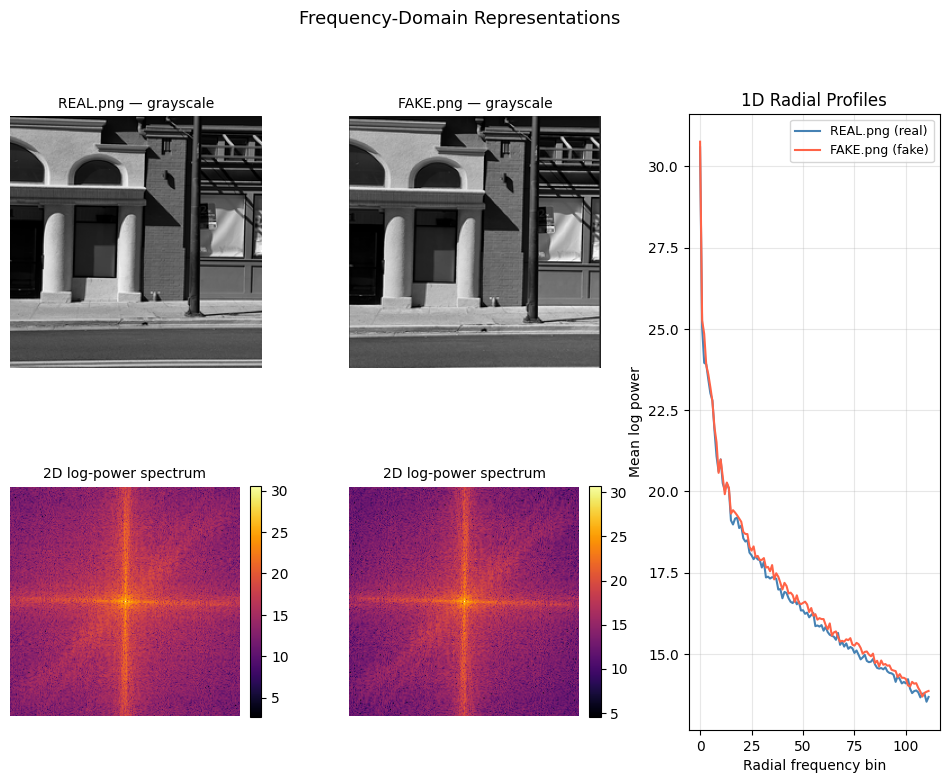

In [3]:
# Pre-compute all representations
size = 224
data = {}
for fname in IMAGES:
    img = Image.open(os.path.join(REPO_ROOT, fname))
    gray = to_grayscale_array(img, size=size)
    spec2d = log_power_spectrum_2d(gray)
    prof1d = azimuthal_average_fast(spec2d)
    data[fname] = {'gray': gray, 'spec2d': spec2d, 'prof1d': prof1d}

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, wspace=0.35, hspace=0.4)

names = list(IMAGES.keys())
colors = ['steelblue', 'tomato']

for col, fname in enumerate(names):
    d = data[fname]
    true_label = IMAGES[fname]

    # Grayscale
    ax0 = fig.add_subplot(gs[0, col])
    ax0.imshow(d['gray'], cmap='gray')
    ax0.set_title(f'{fname} — grayscale', fontsize=10)
    ax0.axis('off')

    # 2D spectrum
    ax1 = fig.add_subplot(gs[1, col])
    im = ax1.imshow(d['spec2d'], cmap='inferno', origin='upper')
    ax1.set_title(f'2D log-power spectrum', fontsize=10)
    ax1.axis('off')
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

# 1D profiles overlaid
ax2 = fig.add_subplot(gs[:, 2])
for fname, color in zip(names, colors):
    prof = data[fname]['prof1d']
    ax2.plot(prof, label=f"{fname} ({IMAGES[fname]})", color=color, linewidth=1.5)
ax2.set_xlabel('Radial frequency bin')
ax2.set_ylabel('Mean log power')
ax2.set_title('1D Radial Profiles')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Frequency-Domain Representations', fontsize=13, y=1.01)
plt.show()

## 3. Model Inference

In [4]:
results = []

for ckpt_path in CHECKPOINTS:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model_type = ckpt['model_type']
    ckpt_size = ckpt.get('args', {}).get('size', 224)
    val_auc = ckpt.get('val_auc', float('nan'))

    model_kwargs = {'input_length': 112} if model_type == '1d' else {}
    model = build_model(model_type, **model_kwargs).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    for fname, true_label in IMAGES.items():
        # Recompute if checkpoint used a different size
        if ckpt_size != size:
            img = Image.open(os.path.join(REPO_ROOT, fname))
            gray = to_grayscale_array(img, size=ckpt_size)
            spec2d = log_power_spectrum_2d(gray)
            prof1d = azimuthal_average_fast(spec2d)
        else:
            spec2d = data[fname]['spec2d']
            prof1d = data[fname]['prof1d']

        t_spec2d = torch.tensor(spec2d).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
        t_prof1d = torch.tensor(prof1d).unsqueeze(0)               # (1,L)
        x = t_prof1d if model_type == '1d' else t_spec2d

        with torch.no_grad():
            probs = torch.softmax(model(x), dim=1)[0]
            p_real = probs[0].item()
            p_fake = probs[1].item()

        pred = 'FAKE' if p_fake >= 0.5 else 'REAL'
        correct = (pred.lower() == true_label)
        results.append({
            'checkpoint': os.path.basename(ckpt_path),
            'model': model_type.upper() + ' CNN',
            'val_auc': val_auc,
            'image': fname,
            'true': true_label,
            'P(real)': p_real,
            'P(fake)': p_fake,
            'pred': pred,
            'correct': correct,
        })

# Print table
hdr = f"{'Checkpoint':<14} {'Model':<10} {'Image':<12} {'True':<6} {'P(real)':>8} {'P(fake)':>8} {'Pred':<6} {'OK?'}"
print(hdr)
print('-' * len(hdr))
for r in results:
    ok = '\u2713' if r['correct'] else '\u2717'
    print(f"{r['checkpoint']:<14} {r['model']:<10} {r['image']:<12} {r['true']:<6} "
          f"{r['P(real)']:>8.4f} {r['P(fake)']:>8.4f} {r['pred']:<6} {ok}")

Checkpoint     Model      Image        True    P(real)  P(fake) Pred   OK?
--------------------------------------------------------------------------
best_1d.pt     1D CNN     REAL.png     real     1.0000   0.0000 REAL   ✓
best_1d.pt     1D CNN     FAKE.png     fake     1.0000   0.0000 REAL   ✗
best_2d.pt     2D CNN     REAL.png     real     0.0000   1.0000 FAKE   ✗
best_2d.pt     2D CNN     FAKE.png     fake     0.0000   1.0000 FAKE   ✓


## 4. Results Visualisation

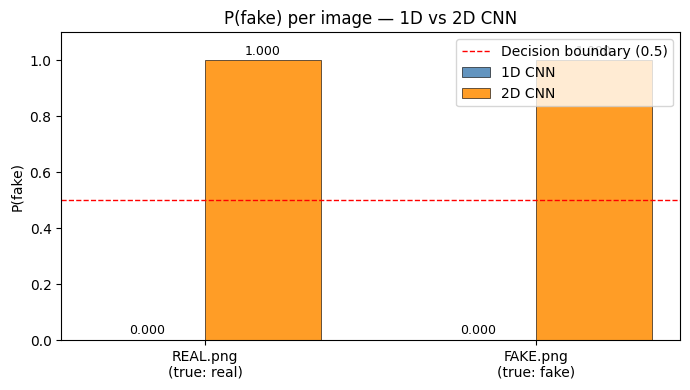

In [5]:
import matplotlib.patches as mpatches

models  = sorted(set(r['model'] for r in results))
imgs    = list(IMAGES.keys())
x       = np.arange(len(imgs))
width   = 0.35
offsets = [-width/2, width/2]

fig, ax = plt.subplots(figsize=(7, 4))
palette = {'1D CNN': 'steelblue', '2D CNN': 'darkorange'}

for model_name, offset in zip(models, offsets):
    probs = [next(r['P(fake)'] for r in results if r['model'] == model_name and r['image'] == img)
             for img in imgs]
    bars = ax.bar(x + offset, probs, width, label=model_name,
                  color=palette.get(model_name, 'gray'), alpha=0.85, edgecolor='k', linewidth=0.5)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{p:.3f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Decision boundary (0.5)')
ax.set_xticks(x)
ax.set_xticklabels([f"{img}\n(true: {IMAGES[img]})" for img in imgs])
ax.set_ylabel('P(fake)')
ax.set_ylim(0, 1.1)
ax.set_title('P(fake) per image — 1D vs 2D CNN')
ax.legend()
plt.tight_layout()
plt.show()